In [1]:
import pickle
import numpy as np 
import re 
from pathlib import Path
import pandas as pd

%matplotlib inline 

import matplotlib.pyplot as plt 
import seaborn as sns
# from matplotlib.ticker import FormatStrFormatter



In [24]:
word_and_speaker_encodings = pickle.load( open( "/om2/user/imgriff/projects/End-to-end-ASR-Pytorch/word_and_speaker_encodings_jsinv3.pckl", "rb" )) 
class_map = word_and_speaker_encodings['word_idx_to_word']


## Get model results on normal speech 

In [59]:
parent_path = Path('/om2/user/imgriff/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_timit_task/TIMIT_attn_task_all_targets_MultiDistractorAttnCNN/version_0/')
harmonic_file = parent_path.rglob("*.csv")



In [60]:
harmonic_results = pd.read_csv(next(harmonic_file))

In [61]:
harmonic_results = harmonic_results.rename(columns={'ACC/test_fg_acc':"accuracy",
                             'step':'orig_df_ix'}, 
                      index={ix:f"trial {ix}" for ix in harmonic_results.index})
harmonic_results['pred_word_ix'] = harmonic_results['pred_word_ix'].astype('int') 

In [62]:
harmonic_results

,accuracy,pred_word_ix,orig_df_ix
trial 0,1.0,552,0
trial 1,0.0,392,1
trial 2,0.0,689,2
trial 3,1.0,659,3
trial 4,0.0,90,4
...,...,...,...
trial 41487,1.0,71,41487
trial 41488,0.0,206,41488
trial 41489,0.0,500,41489
trial 41490,0.0,91,41490


### Get metadata for harmonic stimuli

In [63]:
### import parent model stim df
out_path = Path('/om2/user/imgriff/datasets/timit/attn_task_dataframes/')

model_meta_df = pd.read_pickle(out_path / 'timit_attn_stim_for_model_all_targets_metadata_only.pdpkl')

In [64]:
model_meta_df.head()

,speaker,speaker_sex,sentence_type,word_int,cue_speaker,cue_word,_original_distractor_timit_indices,_original_cue_timit_index,distractor_words,distractor_speakers,...,distractor_sex,snrs,word,_original_timit_index,source,sr,sentence_id,dialect_region,data_split,distractor_word_ints
0,fdaw0,f,sx,552,fdaw0,slowed,[5748],14,[working],[mdrb0],...,m,-6,programs,15,train-dr1-fdaw0-sx146,20000,146,dr1,train,[working]
1,fdaw0,f,sx,461,fdaw0,answer,[6095],13,[medical],[mkdr0],...,m,-6,novel,17,train-dr1-fdaw0-sx326,20000,326,dr1,train,[medical]
2,fdml0,f,sx,646,fdml0,tube,[978],28,[larger],[mrfk0],...,m,-6,should,28,train-dr1-fdml0-sx429,20000,429,dr1,train,[larger]
3,fecd0,f,sx,659,fecd0,wound,[1679],37,[caused],[mmam0],...,m,-6,social,35,train-dr1-fecd0-sx158,20000,158,dr1,train,[caused]
4,fecd0,f,sx,393,fecd0,to,[342],39,[young],[mtpf0],...,m,-6,light,36,train-dr1-fecd0-sx248,20000,248,dr1,train,[young]


In [65]:
harmonic_results['guessed_word'] = harmonic_results['pred_word_ix'].map(class_map)

### Get metadata from timit df 
harmonic_results['true_word'] = model_meta_df.loc[harmonic_results.orig_df_ix, ['word']].values
harmonic_results['distractor_words'] = model_meta_df.loc[harmonic_results.orig_df_ix, ['distractor_words']].values
harmonic_results['distractor_sex'] = model_meta_df.loc[harmonic_results.orig_df_ix, ['distractor_sex']].values
harmonic_results['snr'] = model_meta_df.loc[harmonic_results.orig_df_ix, ['snrs']].values.astype('str')
harmonic_results['distractor_condition'] = model_meta_df.loc[harmonic_results.orig_df_ix, ['distractor_conditions']].values.astype('str')
harmonic_results['target_sex'] = model_meta_df.loc[harmonic_results.orig_df_ix, ['speaker_sex']].values



In [76]:
# get only relevant points of comparison 
harmonic_results = harmonic_results[harmonic_results.snr == '0']
harmonic_results = harmonic_results[harmonic_results.distractor_condition == '1']


In [127]:
harmonic_results['distractor_condition'] = 'Harmonic'

In [90]:
harmonic_results.shape

(1804, 10)

## Get Whispered results

In [18]:
parent_path = Path('/om2/user/imgriff/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_timit_task/TIMIT_whispered_speech_attn_task_0dB_SNR_all_targets_MultiDistractorAttnCNN/version_3/')
whispered_file = parent_path.rglob("*.csv")
whispered_results = pd.read_csv(next(whispered_file))


In [85]:
whispered_results = whispered_results.rename(columns={'ACC/test_fg_acc':"accuracy",
                             'step':'orig_df_ix'}, 
                      index={ix:f"trial {ix}" for ix in harmonic_results.index})
whispered_results['pred_word_ix'] = whispered_results['pred_word_ix'].astype('int') 

### Get whispered meta data

In [87]:
### import parent model stim df
out_path = Path('/om2/user/imgriff/datasets/timit/whispered_timit/')

whisper_meta_data = pd.read_pickle(out_path / 'all_targets_whispered_single_distractor_0dB_SNR.pdpkl')

In [88]:
whispered_results['guessed_word'] = whispered_results['pred_word_ix'].map(class_map)

### Get metadata from timit df 
whispered_results['true_word'] = whisper_meta_data.loc[whispered_results.orig_df_ix, ['word']].values
whispered_results['distractor_words'] = whisper_meta_data.loc[whispered_results.orig_df_ix, ['distractor_words']].values
whispered_results['distractor_sex'] = whisper_meta_data.loc[whispered_results.orig_df_ix, ['distractor_sex']].values
whispered_results['snr'] = whisper_meta_data.loc[whispered_results.orig_df_ix, ['snrs']].values.astype('str')
whispered_results['distractor_condition'] = whisper_meta_data.loc[whispered_results.orig_df_ix, ['distractor_conditions']].values.astype('str')
whispered_results['target_sex'] = whisper_meta_data.loc[whispered_results.orig_df_ix, ['speaker_sex']].values



In [89]:
whispered_results

,accuracy,pred_word_ix,orig_df_ix,guessed_word,true_word,distractor_words,distractor_sex,snr,distractor_condition,target_sex
0,0.0,522,0,power,programs,night,m,0,Whispered,f
1,0.0,526,1,present,novel,present,m,0,Whispered,f
2,0.0,30,2,alternative,should,always,m,0,Whispered,f
3,0.0,667,3,special,social,would,f,0,Whispered,f
4,0.0,771,4,white,light,common,m,0,Whispered,f
...,...,...,...,...,...,...,...,...,...,...
897,1.0,71,897,based,based,production,f,0,Whispered,m
898,0.0,377,898,larger,either,would,m,0,Whispered,m
899,0.0,108,899,carried,through,theory,f,0,Whispered,m
900,0.0,492,900,parts,avoid,always,f,0,Whispered,m


## Get Inharmonic Results

In [115]:
parent_path = Path('/om2/user/imgriff/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_timit_task/TIMIT_inharmonic_speech_attn_task_0dB_SNR_all_targets_MultiDistractorAttnCNN/version_0/')
inharm_file = parent_path.rglob("*.csv")
inharm_results = pd.read_csv(next(inharm_file))


In [116]:
inharm_results = inharm_results.rename(columns={'ACC/test_fg_acc':"accuracy",
                             'step':'orig_df_ix'}, 
                      index={ix:f"trial {ix}" for ix in harmonic_results.index})
inharm_results['pred_word_ix'] = inharm_results['pred_word_ix'].astype('int') 

### Get whispered meta data

In [117]:
### import parent model stim df
out_path = Path('/om2/user/imgriff/datasets/timit/inharmonic_timit/')

inharm_meta_data = pd.read_pickle(out_path / 'all_targets_inharmonic_single_distractor_0dB_SNR.pdpkl')

In [119]:
inharm_results['guessed_word'] = inharm_results['pred_word_ix'].map(class_map)

### Get metadata from timit df 
inharm_results['true_word'] = inharm_meta_data.loc[inharm_results.orig_df_ix, ['word']].values
inharm_results['distractor_words'] = inharm_meta_data.loc[inharm_results.orig_df_ix, ['distractor_words']].values
inharm_results['distractor_sex'] = inharm_meta_data.loc[inharm_results.orig_df_ix, ['distractor_sex']].values
inharm_results['snr'] = inharm_meta_data.loc[inharm_results.orig_df_ix, ['snrs']].values.astype('str')
inharm_results['distractor_condition'] = inharm_meta_data.loc[inharm_results.orig_df_ix, ['distractor_conditions']].values.astype('str')
inharm_results['target_sex'] = inharm_meta_data.loc[inharm_results.orig_df_ix, ['speaker_sex']].values



In [143]:
inharm_results['distractor_condition'] = 'Inharmonic \n (0.3 jitter)'

In [144]:
## combine_dfs 

all_results = pd.concat([harmonic_results, whispered_results, inharm_results], ignore_index=True)

In [145]:
get_confusion = lambda row: int(row.guessed_word in row.distractor_words)

all_results['confusion'] = all_results[['guessed_word', 'distractor_words']].apply(get_confusion, axis=1)


In [146]:
all_results.head()

,accuracy,pred_word_ix,orig_df_ix,guessed_word,true_word,distractor_words,distractor_sex,snr,distractor_condition,target_sex,confusion
0,1.0,552,19844,programs,programs,[there],m,0,Harmonic,f,0
1,0.0,391,19845,level,novel,[these],m,0,Harmonic,f,0
2,1.0,646,19846,should,should,[modern],m,0,Harmonic,f,0
3,1.0,659,19847,social,social,[asked],m,0,Harmonic,f,0
4,0.0,396,19848,lines,light,[contains],m,0,Harmonic,f,0


In [147]:
all_results.distractor_condition.unique()

array(['Harmonic', 'Whispered', 'Inharmonic \n (0.3 jitter)'],
      dtype=object)

In [165]:
spch_rslts = pd.melt(all_results, id_vars=['distractor_condition'],

        value_vars=['accuracy', 'confusion'],
        value_name = 'hits',
        var_name = 'attended_stream')

In [168]:
spch_rslts['attended_stream'] [spch_rslts['attended_stream'] == 'accuracy'] = "Cued stream"
spch_rslts['attended_stream'] [spch_rslts['attended_stream'] == 'confusion']= "Uncued stream"

/tmp/ipykernel_41346/756580794.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spch_rslts['attended_stream'] [spch_rslts['attended_stream'] == 'accuracy'] = "Cued stream"
/tmp/ipykernel_41346/756580794.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spch_rslts['attended_stream'] [spch_rslts['attended_stream'] == 'confusion']= "Uncued stream"


In [169]:
spch_rslts

,distractor_condition,attended_stream,hits
0,Harmonic,Cued stream,1.0
1,Harmonic,Cued stream,0.0
2,Harmonic,Cued stream,1.0
3,Harmonic,Cued stream,1.0
4,Harmonic,Cued stream,0.0
...,...,...,...
6307,Inharmonic \n (0.3 jitter),Uncued stream,1.0
6308,Inharmonic \n (0.3 jitter),Uncued stream,0.0
6309,Inharmonic \n (0.3 jitter),Uncued stream,1.0
6310,Inharmonic \n (0.3 jitter),Uncued stream,0.0


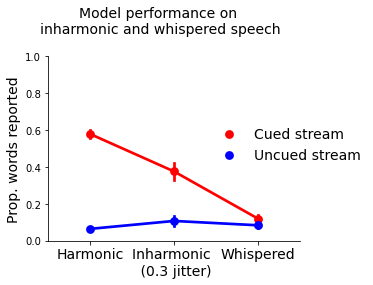

In [189]:
order = ['Harmonic', 'Inharmonic \n (0.3 jitter)', 'Whispered']


hues = ['r', 'b']

fontsize=14


g = sns.catplot(kind='point',
    data=spch_rslts,
    x='distractor_condition', y='hits',
    hue = 'attended_stream',
    palette=hues,
    order = order,
#     hue='distractor_condition', hue_order=hue_order, palette=distractor_palette,
#     col='subject',
    seed=1, 
    height=4, aspect=0.75
)


g.set_axis_labels("", "Prop. words reported", size=fontsize)
g.set_xticklabels(rotation=0, size=fontsize)
# g.set_xticklabels(rotation=0, size=fontsize)

# g.set_yticklabels(size=fontsize)

# g.set_titles("{col_name} performance", size=fontsize)
g.legend.set_title("")
# plt.yscale('log')
sns.move_legend(g, title='', 
                loc="center right", bbox_to_anchor=(1.15, .5),
                frameon=False, title_size=fontsize, fontsize=fontsize)
# plt.tick_params(axis='both', which='major', labelsize=16)

plt.ylim(0,1)
g.fig.subplots_adjust(top=0.9) # adjust the Figure in rp
g.fig.suptitle('Model performance on \ninharmonic and whispered speech', size=fontsize)
g.fig.tight_layout()